# Notebook — Teste do módulo `time_systems.py`

Este notebook testa o módulo:

```python
geodesy/time_systems.py
```

Serão testadas as funções:

- `julian_date`
- `modified_julian_date`
- `datetime_to_julian_date`
- `calendar_to_decimal_year`
- `decimal_year_to_datetime`
- `gps_week_seconds`
- `greenwich_sidereal_time_approx`

Os gráficos são chamados diretamente nas células.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")

import geodesy
from geodesy import time_systems

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Data Juliana


In [2]:
# ============================================================
# 1. DATA JULIANA
# ============================================================

JD = time_systems.julian_date(2025, 9, 1, 0, 0, 0)
MJD = time_systems.modified_julian_date(2025, 9, 1, 0, 0, 0)

print("Data: 2025-09-01 00:00:00")
print("JD:", JD)
print("MJD:", MJD)

JD_noon = time_systems.julian_date(2025, 9, 1, 12, 0, 0)
print("\nJD ao meio-dia:", JD_noon)
print("Diferença em dias:", JD_noon - JD)


Data: 2025-09-01 00:00:00
JD: 2460919.5
MJD: 60919.0

JD ao meio-dia: 2460920.0
Diferença em dias: 0.5


## 2. Conversão `datetime` para Data Juliana


In [3]:
# ============================================================
# 2. DATETIME -> JD
# ============================================================

dt = datetime(2026, 3, 31, 23, 0, 0)

JD_dt = time_systems.datetime_to_julian_date(dt)
MJD_dt = JD_dt - 2400000.5

print("Datetime:", dt)
print("JD:", JD_dt)
print("MJD:", MJD_dt)


Datetime: 2026-03-31 23:00:00
JD: 2461131.4583333335
MJD: 61130.95833333349


## 3. Série temporal de JD e MJD


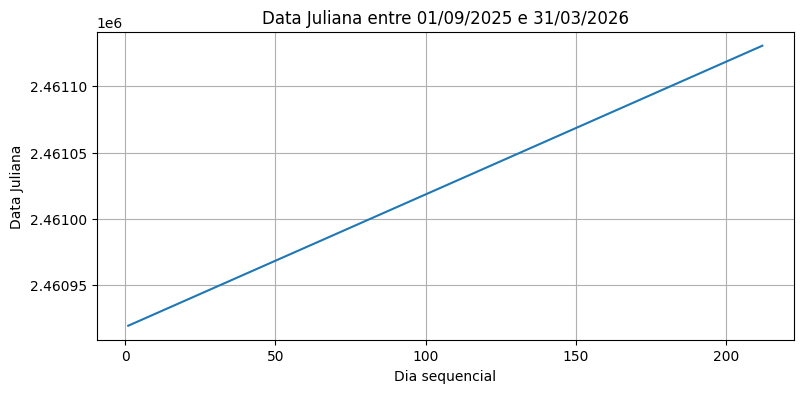

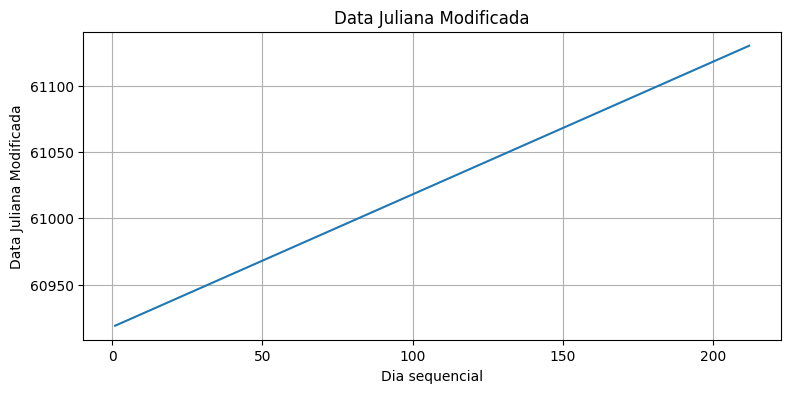

In [4]:
# ============================================================
# 3. SÉRIE TEMPORAL JD E MJD
# ============================================================

datas = [datetime(2025, 9, 1) + timedelta(days=i) for i in range(212)]
JD_series = np.array([time_systems.datetime_to_julian_date(d) for d in datas])
MJD_series = JD_series - 2400000.5

dias = np.arange(1, len(datas) + 1)

plt.figure(figsize=(9, 4))
plt.plot(dias, JD_series)
plt.xlabel("Dia sequencial")
plt.ylabel("Data Juliana")
plt.title("Data Juliana entre 01/09/2025 e 31/03/2026")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(dias, MJD_series)
plt.xlabel("Dia sequencial")
plt.ylabel("Data Juliana Modificada")
plt.title("Data Juliana Modificada")
plt.grid(True)
plt.show()


## 4. Ano decimal


In [5]:
# ============================================================
# 4. ANO DECIMAL
# ============================================================

decimal_1 = time_systems.calendar_to_decimal_year(2025, 1, 1)
decimal_2 = time_systems.calendar_to_decimal_year(2025, 7, 1)
decimal_3 = time_systems.calendar_to_decimal_year(2025, 12, 31, 12, 0, 0)

print("2025-01-01:", decimal_1)
print("2025-07-01:", decimal_2)
print("2025-12-31 12h:", decimal_3)

dt_back = time_systems.decimal_year_to_datetime(decimal_2)
print("\nData recuperada para ano decimal de 2025-07-01:")
print(dt_back)


2025-01-01: 2025.0
2025-07-01: 2025.495890410959
2025-12-31 12h: 2025.9986301369863

Data recuperada para ano decimal de 2025-07-01:
2025-07-01 00:00:00.000002


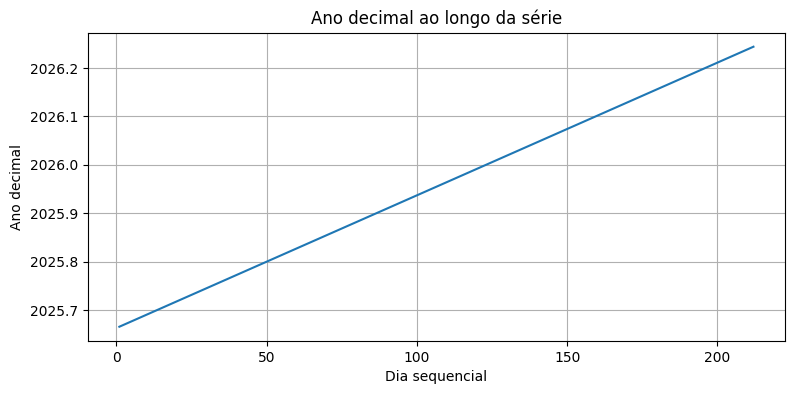

Primeiro ano decimal: 2025.6657534246576
Último ano decimal: 2026.2438356164384


In [6]:
# Ano decimal para uma série de datas

decimal_years = np.array([
    time_systems.calendar_to_decimal_year(d.year, d.month, d.day)
    for d in datas
])

plt.figure(figsize=(9, 4))
plt.plot(dias, decimal_years)
plt.xlabel("Dia sequencial")
plt.ylabel("Ano decimal")
plt.title("Ano decimal ao longo da série")
plt.grid(True)
plt.show()

print("Primeiro ano decimal:", decimal_years[0])
print("Último ano decimal:", decimal_years[-1])


## 5. Conversão ano decimal para `datetime`


In [7]:
# ============================================================
# 5. ANO DECIMAL -> DATETIME
# ============================================================

anos_decimais_teste = [2025.0, 2025.25, 2025.50, 2025.75, 2026.0]

for ay in anos_decimais_teste:
    dt_rec = time_systems.decimal_year_to_datetime(ay)
    print(ay, "->", dt_rec)


2025.0 -> 2025-01-01 00:00:00
2025.25 -> 2025-04-02 06:00:00
2025.5 -> 2025-07-02 12:00:00
2025.75 -> 2025-10-01 18:00:00
2026.0 -> 2026-01-01 00:00:00


## 6. Semana GPS e segundos da semana


In [8]:
# ============================================================
# 6. GPS WEEK E SECONDS OF WEEK
# ============================================================

datas_gps = [
    datetime(1980, 1, 6),
    datetime(2025, 9, 1, 0, 0, 0),
    datetime(2026, 3, 31, 23, 0, 0),
]

for d in datas_gps:
    week, sow = time_systems.gps_week_seconds(d)
    print("Data:", d)
    print("GPS week:", week)
    print("Seconds of week:", sow)
    print("-" * 40)


Data: 1980-01-06 00:00:00
GPS week: 0
Seconds of week: 0.0
----------------------------------------
Data: 2025-09-01 00:00:00
GPS week: 2382
Seconds of week: 86400.0
----------------------------------------
Data: 2026-03-31 23:00:00
GPS week: 2412
Seconds of week: 255600.0
----------------------------------------


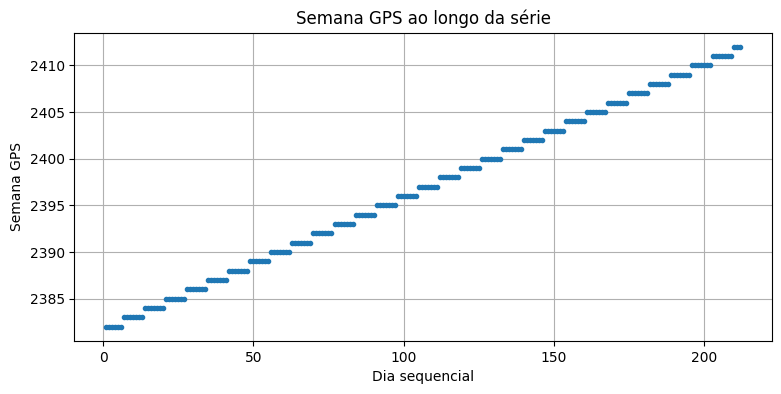

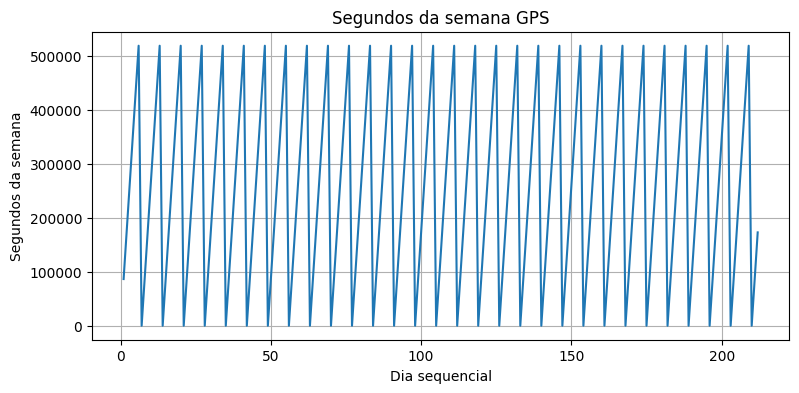

In [9]:
# GPS week ao longo da série 2025-09-01 a 2026-03-31

gps_weeks = []
gps_sow = []

for d in datas:
    w, s = time_systems.gps_week_seconds(d)
    gps_weeks.append(w)
    gps_sow.append(s)

gps_weeks = np.array(gps_weeks)
gps_sow = np.array(gps_sow)

plt.figure(figsize=(9, 4))
plt.plot(dias, gps_weeks, marker=".", linestyle="")
plt.xlabel("Dia sequencial")
plt.ylabel("Semana GPS")
plt.title("Semana GPS ao longo da série")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(dias, gps_sow)
plt.xlabel("Dia sequencial")
plt.ylabel("Segundos da semana")
plt.title("Segundos da semana GPS")
plt.grid(True)
plt.show()


## 7. Tempo sideral médio de Greenwich aproximado


In [10]:
# ============================================================
# 7. TEMPO SIDERAL DE GREENWICH APROXIMADO
# ============================================================

dt_test = datetime(2025, 9, 1, 0, 0, 0)
gst = time_systems.greenwich_sidereal_time_approx(dt_test)

print("Data:", dt_test)
print("GST aproximado:", gst, "graus")


Data: 2025-09-01 00:00:00
GST aproximado: 340.4118792102672 graus


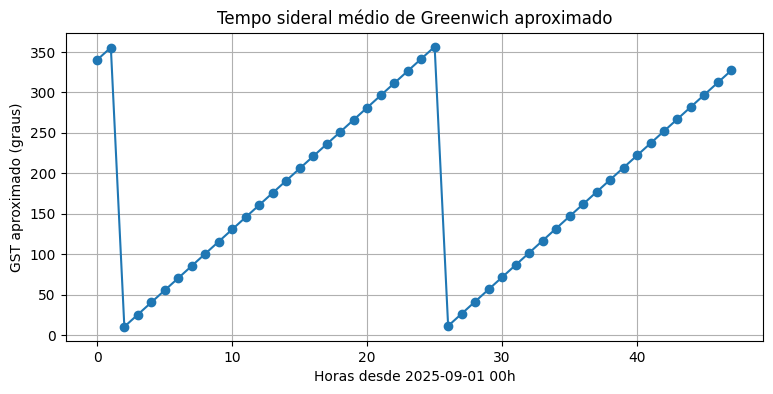

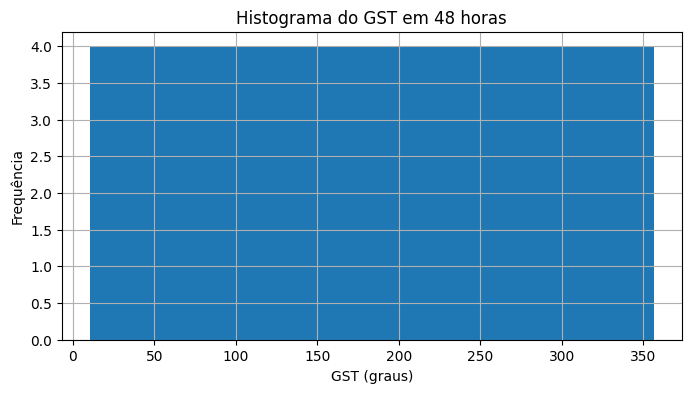

In [11]:
# GST ao longo de 48 horas

horas = np.arange(0, 48, 1)
datas_horarias = [datetime(2025, 9, 1) + timedelta(hours=int(h)) for h in horas]
gst_series = np.array([time_systems.greenwich_sidereal_time_approx(d) for d in datas_horarias])

plt.figure(figsize=(9, 4))
plt.plot(horas, gst_series, marker="o")
plt.xlabel("Horas desde 2025-09-01 00h")
plt.ylabel("GST aproximado (graus)")
plt.title("Tempo sideral médio de Greenwich aproximado")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(gst_series, bins=12)
plt.xlabel("GST (graus)")
plt.ylabel("Frequência")
plt.title("Histograma do GST em 48 horas")
plt.grid(True)
plt.show()


## 8. Mapa didático: GST em função do dia e da hora


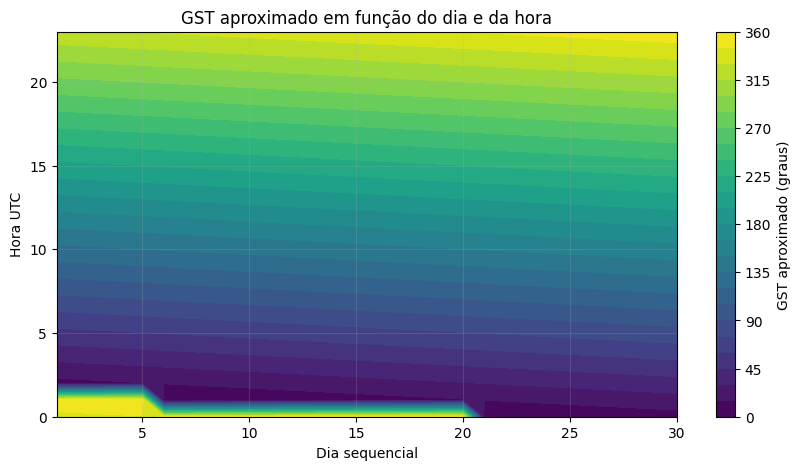

In [12]:
# ============================================================
# 8. CONTOURF: GST EM FUNÇÃO DO DIA E DA HORA
# ============================================================

n_dias = 30
horas_dia = np.arange(0, 24, 1)

DIAS, HORAS = np.meshgrid(np.arange(1, n_dias + 1), horas_dia)
GST_GRID = np.zeros_like(DIAS, dtype=float)

data_inicial = datetime(2025, 9, 1)

for i in range(HORAS.shape[0]):
    for j in range(HORAS.shape[1]):
        dt_current = data_inicial + timedelta(days=int(DIAS[i, j]-1), hours=int(HORAS[i, j]))
        GST_GRID[i, j] = time_systems.greenwich_sidereal_time_approx(dt_current)

plt.figure(figsize=(10, 5))
c = plt.contourf(DIAS, HORAS, GST_GRID, levels=30)
plt.colorbar(c, label="GST aproximado (graus)")
plt.xlabel("Dia sequencial")
plt.ylabel("Hora UTC")
plt.title("GST aproximado em função do dia e da hora")
plt.grid(alpha=0.2)
plt.show()


## 9. Resumo final

Se todas as células foram executadas sem erro, o módulo `time_systems.py` está funcionando corretamente.

O próximo notebook testa:

```python
geodesy/normal_gravity.py
```
